In [8]:
import torch 
from matplotlib import pyplot as plt
import numpy as np
from hnet.synth import generate
from hnet.synth import utils 
from hnet.train.hnet import train_hnet
from hnet.models.HyperNet import HyperNet
from hnet.train.hnet import EnergyDistanceLoss

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Getting Started 

We have developed this package to enable convenient uncertainty quantification with almost any PyTorch model. This method operates on the following premise: 

$$ \theta <- f_{\phi}(z) $$ 
$$ z <- p(z) $$ 
$$ \hat{y} <- f_{\theta}(x) $$

The base model ($f_{\theta}$) can be almost any PyTorch module (doesn't work with BatchNorm layers currently). The hypernetwork ($f_{\phi}(z)$) transforms an input code (z) sampled from some probability distribution (p(z)). Using PyTorchs native `vmap` functionality, the hypernetwork can efficiently sample many codes, each of which provies a unique paramterization of $\theta$ and can be thought of as a distribution over $\theta$, which provides a distribution over $\hat{y}$.   

To begin, let's generate some synthetic data. 

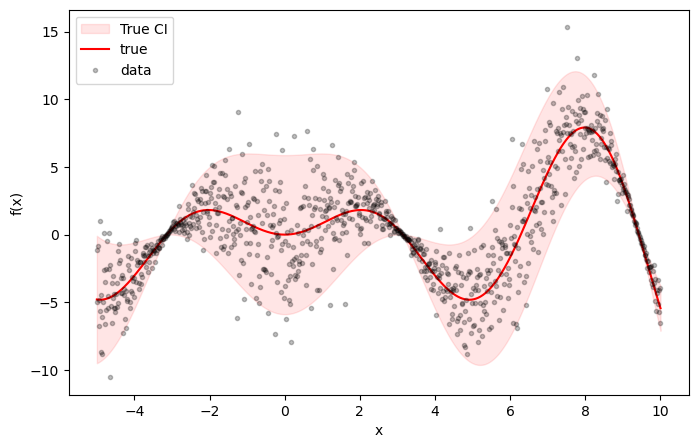

In [3]:
x,y,y_true,true_lcb,true_ucb = generate.simple1d(N=1000, scale=3)

utils.plot1d(x,y,y_true,true_lcb,true_ucb)

# First, define a base model. 

In this case, the base model is a simple MLP. 

In [ ]:
class MLP(torch.nn.Module): 
    def __init__(self): 
        super().__init__()
        self.f = torch.nn.Sequential(
            torch.nn.Linear(1, 100),
            torch.nn.ReLU(),
            torch.nn.Linear(100, 100),
            torch.nn.ReLU(),
            torch.nn.Linear(100, 1)
        )

    def forward(self, x): 
        return self.f(x)

# Next, wrap the base model in our Hypernetwork 

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

base_model = MLP()
model = HyperNet(base_model, stochastic_channels=10, width=100, pz='normal', learn_pz=True).to(device)

crit = EnergyDistanceLoss()
optim = torch.optim.Adam(model.parameters(), lr=1e-4) 


# Optimize the hypernetwork 

In [17]:
for i in range(100): 

    loss = 0
    jj = 0
    for ixs in torch.split(torch.randperm(len(x)), 256):

        x_batch = x[ixs].to(device).unsqueeze(1)
        y_batch = y[ixs].to(device).unsqueeze(1)

        optim.zero_grad()
        yhat = model(x_batch, samples=250)
        loss = crit(yhat, y_batch)
        loss.backward()
        optim.step()
        loss += loss.item() ; jj += 1

    if i % 10 == 0: print(f'Epoch {i} loss: {loss/jj}')



Epoch 0 loss: 1.8038995265960693
Epoch 10 loss: 1.9194214344024658
Epoch 20 loss: 1.7075750827789307
Epoch 30 loss: 1.6870601177215576
Epoch 40 loss: 1.672031044960022
Epoch 50 loss: 1.5437527894973755
Epoch 60 loss: 1.399338960647583
Epoch 70 loss: 1.1421277523040771
Epoch 80 loss: 1.156284213066101
Epoch 90 loss: 1.1466649770736694


# Plot the results

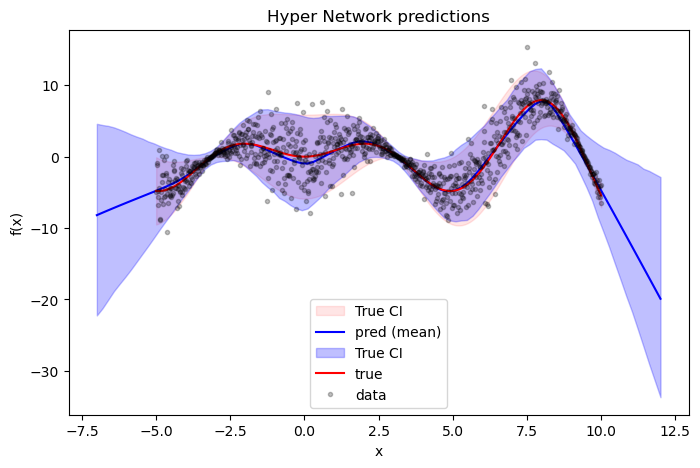

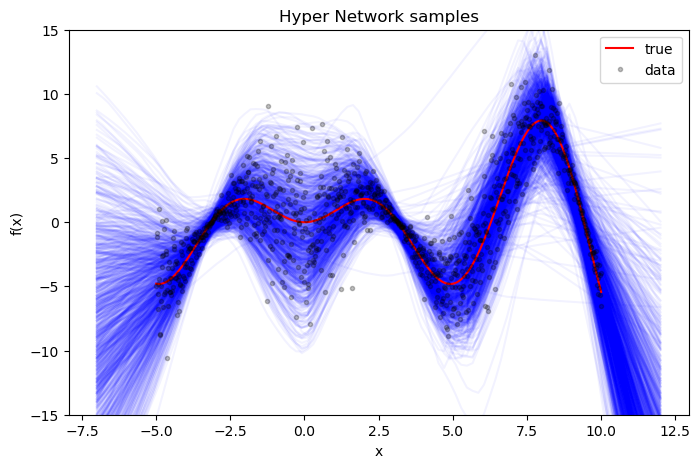

In [21]:
x2 = torch.linspace(-7,12,100)
yhat = model(x2.unsqueeze(1).to(device), 1000)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title=f'Hyper Network predictions')
utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title=f'Hyper Network samples', plot_ci=False, ylim=(-15,15))

# Utility functions 

We have also provided several utility functions for convenient use. 

training on cuda


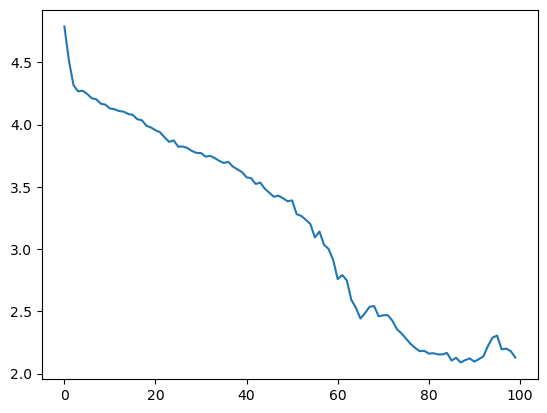

In [3]:
num_epochs = 100
samples = 250       # how many samples to draw from the hypernetwork at each forward pass 
batch_size = 250
lr = 1e-4
obj = 'edl'         # 'mse' , 'nll'  # 'ce' for classification 

hnet_kwargs = {'stochastic_channels':10, 
               'width':100,  
               'pz':'normal', 
               'learn_pz':True}      # learn the distribution of z using normalizing flows. 

mlp_kwargs = {'hidden_channels':100, 
              'layers':2, 'nonlin':'elu'}

model, losses = train_hnet(x.view(-1,1),y.view(-1,1), loss_fn='edl', mlp_kwargs=mlp_kwargs, hnet_kwargs=hnet_kwargs,
                lr=lr, batch_size=batch_size, num_epochs=num_epochs, use_cuda=True)

plt.figure()
plt.plot(losses)
plt.show()


# Plot the credible intervals (predicted vs true)

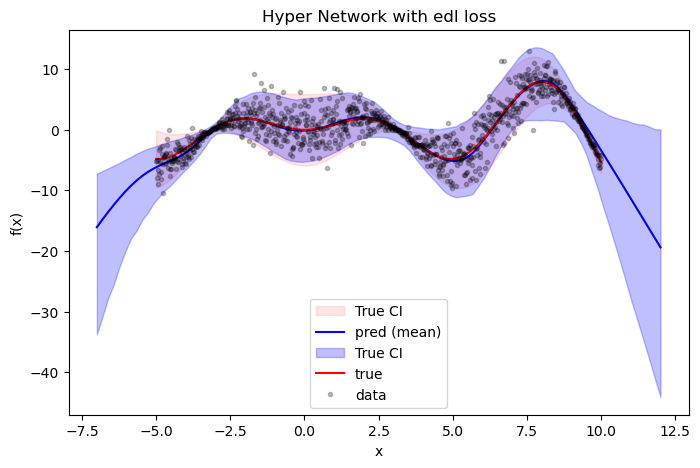

In [4]:
x2 = torch.linspace(-7,12,100)
yhat = model(x2.unsqueeze(1), 1000)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title=f'Hyper Network with {obj} loss')

# Plot the predicted samples 

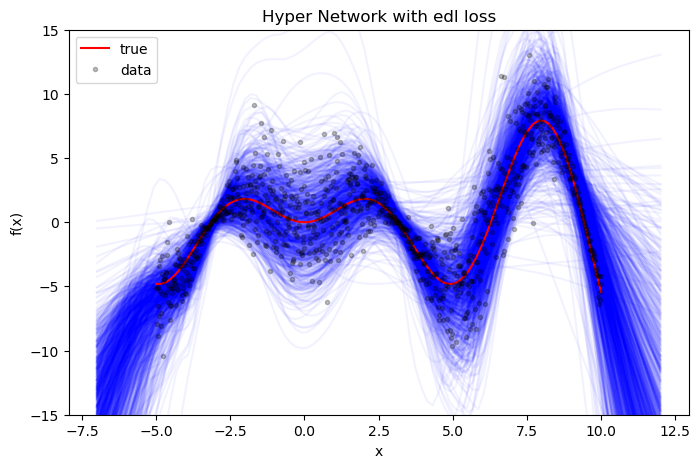

In [5]:
utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title=f'Hyper Network with {obj} loss', plot_ci=False, ylim=(-15,15))